# IMDB Sentiment Analysis (Beginner Friendly)

In this notebook, we will follow a simple ML workflow:
1. Load data
2. Explore data (EDA)
3. Clean text (preprocessing)
4. Train models
5. Evaluate models
6. Improve models
7. Save final model and test on custom reviews

In [30]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# For splitting data into train and test sets
from sklearn.model_selection import train_test_split

In [31]:
# Load the dataset
# This CSV has two columns: review text and sentiment label
# sentiment is usually 'positive' or 'negative'
df = pd.read_csv("IMDB Dataset.csv")

In [32]:
# Check the number of rows and columns
# Output format: (rows, columns)
df.shape

(50000, 2)

In [33]:
# See first 5 rows to understand data format
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 2. EDA (Exploratory Data Analysis)

Goal: understand class balance (positive vs negative).

If classes are balanced, model training is usually easier and fairer.

In [34]:
# Count how many positive and negative reviews are present
class_counts = df["sentiment"].value_counts()
print(class_counts)

# Convert counts to percentage
print()
print(f"positive %: {class_counts['positive'] / len(df) * 100:.2f}%")
print(f"negative %: {class_counts['negative'] / len(df) * 100:.2f}%")

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

positive %: 50.00%
negative %: 50.00%


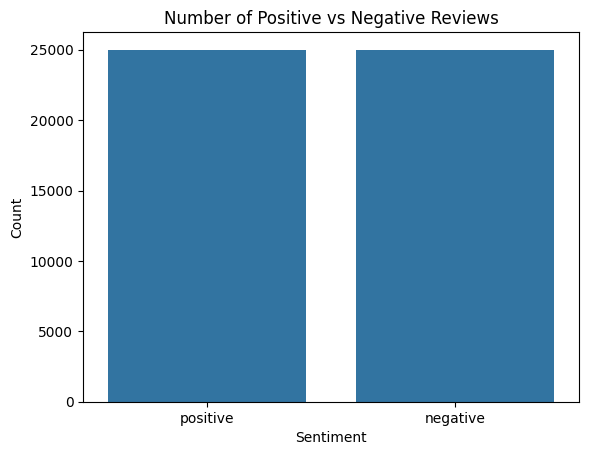

In [35]:
# Visualize class distribution
sns.countplot(x="sentiment", data=df)
plt.title("Number of Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## 3. Preprocessing (Text Cleaning)

We clean text before modeling because raw text has noise.

We will remove:
- HTML tags (`<br />`)
- uppercase by converting to lowercase
- punctuation
- numbers
- stopwords (common words like `the`, `is`, `to`)

In [36]:
# Libraries for text cleaning
import re
import string

# Built-in English stopword list from scikit-learn
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [37]:
def clean_text(text):
    # Convert any input to string (safe for missing values)
    text = str(text)

    # 1) Remove HTML tags, e.g. <br />
    text = re.sub(r"<.*?>", " ", text)

    # 2) Convert to lowercase
    text = text.lower()

    # 3) Remove numbers
    text = re.sub(r"\d+", " ", text)

    # 4) Remove punctuation symbols
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 5) Remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]

    # 6) Join back and remove extra spaces
    cleaned_text = " ".join(tokens).strip()
    return cleaned_text

In [38]:
# Apply cleaning function to every review
df["review_clean"] = df["review"].apply(clean_text)

# Compare original and cleaned text
# This helps verify if cleaning worked correctly
df[["review", "review_clean", "sentiment"]].head(3)

,review,review_clean,sentiment
0,One of the other reviewers has mentioned that ...,reviewers mentioned watching just oz episode y...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive


## 4. Model Training (Baseline)

We start with a simple and strong NLP baseline:
- `TfidfVectorizer`: converts text into numeric features
- `LogisticRegression`: classification model for positive/negative labels

In [39]:
# Text feature extraction + classification model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [40]:
# X = input text, y = target label
X = df["review_clean"]
y = df["sentiment"].map({"negative": 0, "positive": 1})

# Split into train and test data
# stratify=y keeps class balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size : {len(X_test)}")

Train size: 40000
Test size : 10000


In [41]:
# Build a baseline pipeline
# Step 1: TF-IDF vectorizer
# Step 2: Logistic Regression classifier
baseline_model = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=1000)),
    ]
)

# Train model on training data
baseline_model.fit(X_train, y_train)

# Predict on test data
y_pred = baseline_model.predict(X_test)

## 5. Model Evaluation

We evaluate with:
- Accuracy (overall correct predictions)
- Classification report (precision, recall, F1)
- Confusion matrix (types of mistakes)

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {acc:.4f}")
print()

# Detailed metrics for each class
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

Baseline Accuracy: 0.8992

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



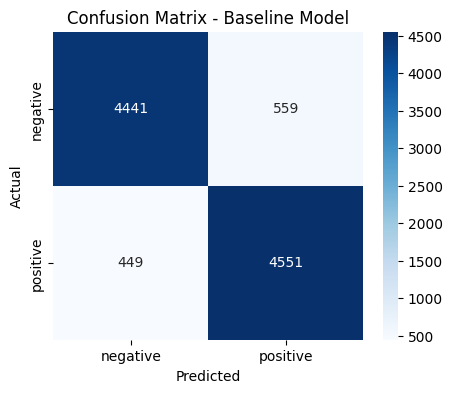

In [43]:
# Confusion matrix shows counts of correct/incorrect predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")
plt.show()

## 6. Improve Baseline with Another Model

Now we compare Logistic Regression with Naive Bayes.

Learning idea: try one change at a time and compare metrics.

In [44]:
from sklearn.naive_bayes import MultinomialNB

# Build second model pipeline
nb_model = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)),
        ("clf", MultinomialNB()),
    ]
)

# Train and predict
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Evaluate quickly
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {acc_nb:.4f}")

Naive Bayes Accuracy: 0.8704


In [45]:
# Compare model performance in one table
results = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "MultinomialNB"],
        "Accuracy": [acc, acc_nb],
    }
).sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
0,Logistic Regression,0.8992
1,MultinomialNB,0.8704


## 7. Hyperparameter Tuning with Grid Search

Hyperparameters are settings we choose before training.

`GridSearchCV` tries all combinations from a small list and picks the best one by cross-validation.

In [46]:
from sklearn.model_selection import GridSearchCV

# Define a pipeline to tune
tuned_pipe = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(max_iter=1000)),
    ]
)

# Small grid (beginner-friendly and faster)
param_grid = {
    "tfidf__max_features": [10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 5],
    "clf__C": [0.5, 1.0, 2.0],
}

# Try every combination
grid = GridSearchCV(
    estimator=tuned_pipe,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
)

grid.fit(X_train, y_train)

# Best model from grid search
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best Params:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.4f}")

Best Params: {'clf__C': 2.0, 'tfidf__max_features': 20000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.8926


## 8. Better Evaluation (ROC-AUC and Threshold)

- Accuracy uses one default threshold (0.5)
- ROC-AUC checks ranking quality across all thresholds
- You can change threshold depending on business goal

Tuned Model Accuracy: 0.9032
Tuned Model ROC-AUC : 0.9640


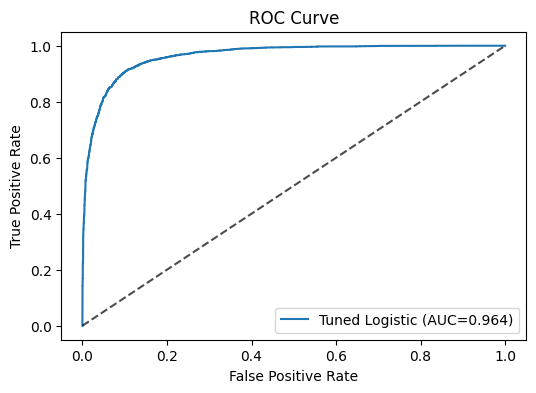

Threshold 0.3 -> Accuracy: 0.8721, F1: 0.8831
Threshold 0.5 -> Accuracy: 0.9032, F1: 0.9040
Threshold 0.7 -> Accuracy: 0.8730, F1: 0.8616


In [47]:
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

# Probability of positive class (1)
y_proba_best = best_model.predict_proba(X_test)[:, 1]
auc_best = roc_auc_score(y_test, y_proba_best)

print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Tuned Model ROC-AUC : {auc_best:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Tuned Logistic (AUC={auc_best:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Try multiple thresholds manually
for threshold in [0.3, 0.5, 0.7]:
    y_pred_th = (y_proba_best >= threshold).astype(int)
    print(
        f"Threshold {threshold:.1f} -> "
        f"Accuracy: {accuracy_score(y_test, y_pred_th):.4f}, "
        f"F1: {f1_score(y_test, y_pred_th):.4f}"
    )

## 9. Error Analysis

To improve model quality, inspect wrong predictions:
- False Positive: actual negative, predicted positive
- False Negative: actual positive, predicted negative

In [48]:
# Build a table with predictions and probabilities
pred_df = pd.DataFrame(
    {
        "review": X_test,
        "actual": y_test,
        "pred": y_pred_best,
        "prob_positive": y_proba_best,
    }
).reset_index(drop=True)

# Find mistakes
false_positives = pred_df[(pred_df["actual"] == 0) & (pred_df["pred"] == 1)]
false_negatives = pred_df[(pred_df["actual"] == 1) & (pred_df["pred"] == 0)]

print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

# Show sample false positives
print("\nSample False Positives:")
for i, row in false_positives.head(3).iterrows():
    print(f"\nCase {i + 1} | prob_positive={row['prob_positive']:.3f}")
    print(row["review"][:350], "...")

# Show sample false negatives
print("\nSample False Negatives:")
for i, row in false_negatives.head(3).iterrows():
    print(f"\nCase {i + 1} | prob_positive={row['prob_positive']:.3f}")
    print(row["review"][:350], "...")

False Positives: 526
False Negatives: 442

Sample False Positives:

Case 2 | prob_positive=0.599
story bride fair amusing engaging filmmakers credit sets portray rural minnesotans respect ordinarily reserved coastdwellers weird independent movie brainchild single person unambitious clichéridden committeebrewed hollywood potboiler portrait rural people intended affectionate think characters dont ring true mei quite meals smalltown diners overhe ...

Case 8 | prob_positive=0.799
movie really wack really nice say moral truth expressed films climax concerning people neighborhood participating fight crime film good shots good acting good script film f ...

Case 15 | prob_positive=0.668
little quentin mastered art having cake eating usual pure sadistic display explained clever thoughtprovoking way sending violence audiences face sure mr tarantino violence baaad sadism baaad worth wading make point brilliant juvenile audience clever follow smart references higher levels consciousness im confi

## 10. TF-IDF Feature Importance

For Logistic Regression:
- Positive coefficient -> pushes prediction to positive
- Negative coefficient -> pushes prediction to negative

This gives model interpretability.

In [49]:
# Get vectorizer and classifier from tuned model
vectorizer = best_model.named_steps["tfidf"]
classifier = best_model.named_steps["clf"]

# Get feature names and their logistic regression weights
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = classifier.coef_[0]

# Select top words
n_top = 20
top_positive_idx = np.argsort(coefs)[-n_top:][::-1]
top_negative_idx = np.argsort(coefs)[:n_top]

# Build easy-to-read tables
top_positive = pd.DataFrame(
    {
        "word": feature_names[top_positive_idx],
        "weight": coefs[top_positive_idx],
    }
)

top_negative = pd.DataFrame(
    {
        "word": feature_names[top_negative_idx],
        "weight": coefs[top_negative_idx],
    }
)

print("Top Positive Words:")
display(top_positive)

print("Top Negative Words:")
display(top_negative)

Top Positive Words:


,word,weight
0,great,8.658883
1,excellent,8.297821
2,perfect,6.577481
3,best,6.321817
4,amazing,6.291584
5,wonderful,5.734595
6,hilarious,5.689284
7,loved,5.313136
8,favorite,5.181709
9,fun,5.075158


Top Negative Words:


,word,weight
0,worst,-11.599344
1,awful,-9.672504
2,bad,-8.957079
3,waste,-8.730057
4,boring,-7.724944
5,poor,-6.757132
6,poorly,-6.602040
7,terrible,-6.572919
8,dull,-6.523830
9,worse,-6.471692


## 11. Faster Tuning with Randomized Search

Why this step:
- Grid search checks all combinations (can be slow)
- Randomized search checks only a random sample
- Good when search space is bigger

In [50]:
from sklearn.model_selection import RandomizedSearchCV

# Pipeline for randomized tuning
random_pipe = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(max_iter=1500)),
    ]
)

# Larger search space (still beginner-friendly)
param_distributions = {
    "tfidf__max_features": [10000, 20000, 30000, 40000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__sublinear_tf": [True, False],
    "clf__C": np.logspace(-2, 1, 15),
}

# Randomly sample combinations (faster than full grid)
random_search = RandomizedSearchCV(
    estimator=random_pipe,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
)

# Train search
random_search.fit(X_train, y_train)

# Final model from randomized search
final_model = random_search.best_estimator_
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print("Best Params (RandomizedSearchCV):", random_search.best_params_)
print(f"Best CV F1 (RandomizedSearchCV): {random_search.best_score_:.4f}")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}")

Best Params (RandomizedSearchCV): {'tfidf__sublinear_tf': True, 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 5, 'tfidf__max_features': 30000, 'clf__C': np.float64(6.105402296585327)}
Best CV F1 (RandomizedSearchCV): 0.8964
Final Test Accuracy: 0.9048
Final Test ROC-AUC: 0.9660


## 12. Save Final Model and Test on New Reviews

This step simulates real-world usage:
1. Save model to file
2. Load it later
3. Predict sentiment for new custom text

In [51]:
import joblib

# Save final trained pipeline to disk
model_path = "imdb_sentiment_pipeline.joblib"
joblib.dump(final_model, model_path)
print(f"Saved model to: {model_path}")

# Load model back from disk
loaded_model = joblib.load(model_path)

# New example reviews for testing
custom_reviews = [
    "This movie was absolutely fantastic, I loved every scene and performance.",
    "The plot was boring and the acting was terrible.",
    "Great visuals but the story was weak and too long.",
]

# Apply same cleaning used in training
custom_reviews_clean = [clean_text(text) for text in custom_reviews]

# Predict sentiment and probability
custom_pred = loaded_model.predict(custom_reviews_clean)
custom_proba = loaded_model.predict_proba(custom_reviews_clean)[:, 1]

# Convert numeric labels back to text labels
label_map = {0: "negative", 1: "positive"}

# Show final inference output
inference_df = pd.DataFrame(
    {
        "review": custom_reviews,
        "clean_review": custom_reviews_clean,
        "pred_label": [label_map[p] for p in custom_pred],
        "prob_positive": custom_proba,
    }
)

inference_df

Saved model to: imdb_sentiment_pipeline.joblib


,review,clean_review,pred_label,prob_positive
0,"This movie was absolutely fantastic, I loved e...",movie absolutely fantastic loved scene perform...,positive,0.970748
1,The plot was boring and the acting was terrible.,plot boring acting terrible,negative,0.001231
2,Great visuals but the story was weak and too l...,great visuals story weak long,positive,0.505330
